
## NIO and cost






## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')

(28, 'o_coke_rt')



In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime
## !pip install pandas
## !pip install scikit-learn
## !pip install matplotlib
## !pip install seaborn
## !pip install mlxtend
## ! pip install skl2onnx



In [2]:


import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)

import os, json, time, uuid


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [3]:


import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt




/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/onnx_ops.py:159: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  tys = obj.typeStr or ''
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/automation.py:154: UserWarning: OpSchema.FormalParameter.isHomogeneous is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.is_homogeneous instead.
  if getattr(obj, 'isHomogeneous', False):
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/jinja2/environment.py:485: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  return getattr(obj, attribute)


In [4]:

import PDFshapingUtils as PDF_tk


In [5]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()


In [6]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [7]:

## Ty suggested fix where 0 needs to be 300

PDFshapingOBJ.CFD_raw_data["i_h2_temp"] = PDFshapingOBJ.CFD_raw_data["i_h2_temp"].replace(0, 300)


In [8]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,300,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


In [9]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

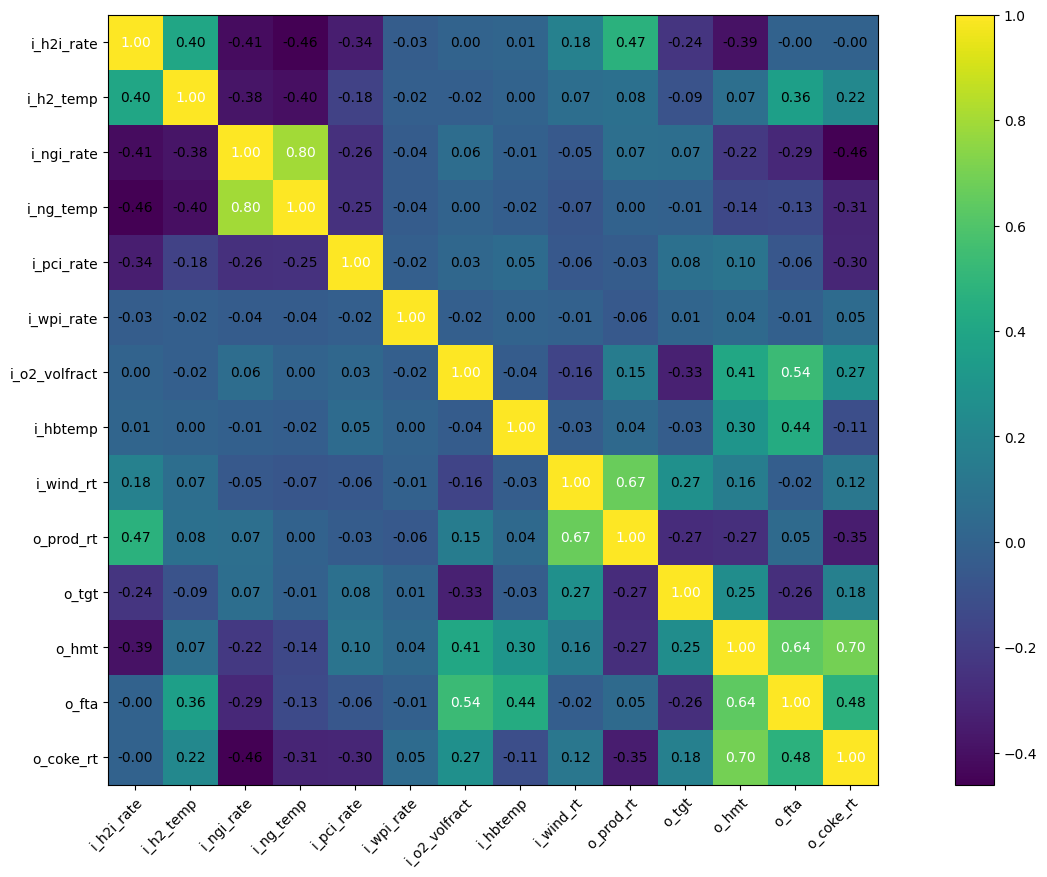

In [10]:


PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','o_prod_rt', 'o_tgt', 'o_hmt','o_fta', 'o_coke_rt']



PDFshapingOBJ.print_correlation_coefficients()


In [11]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)


In [12]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [  2, 3, 5, 6, 8, 9, 10   ] , 
                   outputs= [ 27, 29, 39, 40, 28 ]   
)


## inputs = [ 2, 3, 5, 6, 8, 9, 10  ]          ## the full 7



7
5


In [13]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 7)
(4999, 5)


In [14]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [15]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [16]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [17]:

'''


from sklearn.decomposition import PCA

# Instantiate PCA to reduce to 4 components
pca = PCA(n_components=4)

# Fit on training data and transform both train and test
X_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)
X_test_pca  = pca.transform(PDFshapingOBJ.X_test)

# Replace the original inputs with PCA-reduced versions
PDFshapingOBJ.X_train = X_train_pca
PDFshapingOBJ.X_test  = X_test_pca


'''


'\n\n\nfrom sklearn.decomposition import PCA\n\n# Instantiate PCA to reduce to 4 components\npca = PCA(n_components=4)\n\n# Fit on training data and transform both train and test\nX_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)\nX_test_pca  = pca.transform(PDFshapingOBJ.X_test)\n\n# Replace the original inputs with PCA-reduced versions\nPDFshapingOBJ.X_train = X_train_pca\nPDFshapingOBJ.X_test  = X_test_pca\n\n\n'

In [18]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [19]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [20]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [21]:


PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## Model Forward ( 7x4 )


In [22]:

n_inputs  = 7     ## 7
n_outputs = 5




#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO_Forward(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations,  device='cuda'):
        super().__init__()
        self.device = device
        
        ## self.x_means      = x_means
        ## self.x_deviations = x_deviations
        ## self.y_means      = y_means
        ## self.y_deviations = y_deviations
        
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)
        
        
        
        ## F1
        self.f1_linear1 = nn.Linear(n_inputs, n_outputs)       
        
        ## F2
        self.f2_linear1 = nn.Linear(n_inputs, 10)
        self.f2_act1    = nn.Tanh()   ## nn.Sigmoid()    ## Tanh()    nn.ReLU()                 
        self.f2_linear2 = nn.Linear(10, n_outputs)       
        self.f2_dropout = nn.Dropout(0.25)
        
        # Move model to device
        self.to(self.device)
        
        
    ## perform inference
    def forward(self, x):
        x = x.to(self.device)
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        ##   y_descaled = torch.clamp(  y_descaled, min=0.0  )
        
        return y_descaled, y_scaled
    




In [23]:

n_inputs  = 7    ## 7
n_outputs = 5





    
class ResidualNet_Forward(nn.Module):
    def __init__(self, x_means, x_deviations, y_means, y_deviations, dropout_rate=0.1, device='cuda'):
        
        super().__init__()
        self.device = device
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)

     
        self.fc1  = nn.Linear(n_inputs, 64)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(64, 64)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(64, n_outputs)

        # If input_dim ≠ 64, project for residual addition
        self.input_proj = nn.Linear(n_inputs, 64) if n_inputs != 64 else nn.Identity()
        
        # Move model to device
        self.to(self.device)
        

    def forward(self, x):
        x  = x.to(self.device)
        x  = (x - self.x_means) / self.x_deviations
        x0 = self.input_proj(x)
        x1 = self.dropout1(self.act1(self.fc1(x)))
        x2 = self.dropout2(self.act2(self.fc2(x1)))
        x_res = x2 + x0
        y_scaled = self.fc3(x_res)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

    


In [24]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## model_Forward     = F1plusF2_SIO_Forward(

model_Forward     =     F1plusF2_SIO_Forward(
                         PDFshapingOBJ.x_means, 
                         PDFshapingOBJ.x_deviations, 
                         PDFshapingOBJ.y_means, 
                         PDFshapingOBJ.y_deviations,
                         device=device  # pass device into the model
    
)

optimizer = optim.Adam(model_Forward.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()



In [25]:

model_Forward.train()

for epoch in range(1000):
    for xb, yb in PDFshapingOBJ.train_dl:
        
        xb = xb.to(model_Forward.device)
        yb = yb.to(model_Forward.device)
        
        optimizer.zero_grad()
        pred_descaled, pred_scaled = model_Forward(xb)
        
        loss = loss_fn(pred_scaled, yb)
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(epoch, ".....", loss.item() ) 
    



0 ..... 0.7417215704917908
100 ..... 0.375975102186203
200 ..... 0.15061995387077332
300 ..... 0.17684043943881989
400 ..... 0.2265455424785614
500 ..... 0.4801237881183624
600 ..... 0.1976417601108551
700 ..... 0.39046746492385864
800 ..... 0.3210560977458954
900 ..... 0.13615651428699493


In [26]:

print("=== SANITY CHECK: SCALING ===")
print("y_means:", PDFshapingOBJ.y_means)
print("y_deviations:", PDFshapingOBJ.y_deviations)

print("===============================================")

print("x_means:", PDFshapingOBJ.x_means)
print("x_deviations:", PDFshapingOBJ.x_deviations)


=== SANITY CHECK: SCALING ===
y_means: tensor([[  97.7454, 1300.7876, 8439.3340, 2308.8413,  417.6465]])
y_deviations: tensor([[  50.5408,  521.1359, 1514.3469,  210.9463,   49.4145]])
x_means: tensor([[  12.5231,   18.6152,   41.0313,   25.6124,  420.1801, 1439.0938,
          198.5972]])
x_deviations: tensor([[ 15.2489,  45.3841,  46.5178,   3.3029, 276.5839, 158.2788,  26.7123]])


In [27]:

print(PDFshapingOBJ.y_means -  PDFshapingOBJ.y_deviations)
print(PDFshapingOBJ.y_means +  PDFshapingOBJ.y_deviations)


tensor([[  47.2046,  779.6517, 6924.9873, 2097.8950,  368.2320]])
tensor([[ 148.2863, 1821.9235, 9953.6807, 2519.7876,  467.0611]])


In [28]:

print(PDFshapingOBJ.x_means -  PDFshapingOBJ.x_deviations)
print(PDFshapingOBJ.x_means +  PDFshapingOBJ.x_deviations)


tensor([[  -2.7258,  -26.7689,   -5.4866,   22.3095,  143.5961, 1280.8149,
          171.8849]])
tensor([[  27.7721,   63.9992,   87.5491,   28.9153,  696.7640, 1597.3726,
          225.3094]])


In [29]:

import numpy as np
from numpy.linalg import norm

# --- distance function ---
def euclid(a, b):
    return norm(a - b)



## Now add Costs


In [30]:

def regularize_z(z, strength=1e-3):
    
    return strength * torch.sum(z**2)


In [31]:

clamp_min = torch.tensor([[   0,   0,   0,    21,   300,   1200, 150 ]])     ## from Ty
clamp_max = torch.tensor([[ 300, 300, 300,    90,  3000,   1500, 220 ]])



get_x_from_z = lambda z: clamp_min + (clamp_max - clamp_min) * torch.sigmoid(z)


In [32]:

def wrapped_model(x):
    y_descaled, _ = model_Forward(x)
    return y_descaled  


In [33]:

price_real = np.array([4.0, 1.0, 0.5, 0.0, 0.0, 0.0, 0.0])

price_real = torch.tensor(price_real, dtype=torch.float32)


model_Forward.eval()


for p in model_Forward.parameters():
    p.requires_grad = False



In [34]:

lambda_cost = 0.01        ## 0.1    ## 0.001   ## this gave 86% percent of cases improvement
## lambda_cost = 0.0

dist_method_A = []
dist_method_B = []
cost_diffs    = [] 
cost_diff     = 0

actual_pred_cost = []
actual_real_cost = []

percent_diffs = []
percent_diff  = 0 

learning_rate = 0.01        ## 0.001      ## 1e-5


In [35]:



for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    target_y  = (target_y  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
    
    ## x_starting_point = torch.tensor(   PDFshapingOBJ.X_test[0]   )    ## starting point
    ## x_temp = x_starting_point.clone().detach().requires_grad_(True)
    ## z_init = torch.rand((1,7))*0.4 + 0.3
    
    z_init = torch.rand((1,7))*0.2 + 0.3
    z = torch.nn.Parameter(torch.logit(z_init))    ## this requires grad 
          

    ## x_temp = torch.randn_like(x_starting_point).requires_grad_(True)

    optimizer = torch.optim.Adam([z], lr=learning_rate)
    
   
    
    for j in range(2000):             ## 1000
        
        optimizer.zero_grad()
        
        x_temp = get_x_from_z(  z  )
        
        _, current_y = model_Forward(x_temp)
        
        
        loss_z_reg = regularize_z(z, strength=1e-3)
        loss_main  = torch.mean((current_y - target_y)**2)
        ## loss_cost  = lambda_cost * torch.dot(price_real, x_temp)
        loss_cost  = lambda_cost * (x_temp @ price_real)
        loss       = loss_main + loss_cost + loss_z_reg
        
        loss.backward()
        optimizer.step()
        
        
    
        #######################
        
     
        x_temp_pred_np   = x_temp.detach().numpy()
        ## cost_pred        = np.dot(   price_real, x_temp_pred_np)
        cost_pred        = torch.dot(price_real, x_temp.squeeze()).item()
        
        x_real_np        = x_real.detach().numpy() 
        cost_real        = np.dot(price_real, x_real_np)
       
        if j % 400 == 0:           ## 20
            print(f"iteration {j} cost: {cost_pred}...H2, PCI, NGI:", x_temp_pred_np[:,:3] )
            print("real cost       :", cost_real)
            print( "total loss", loss      )
            print( "loss_main",  loss_main )
            print( "loss_cost",  loss_cost )
        
   
        cost_diff = cost_pred - cost_real
        if cost_real > 0:                         ## handle nans
            percent_diff = cost_diff / cost_real
            percent_diffs.append(percent_diff)
        
          
    cost_diffs.append(    cost_diff  )
    
    actual_pred_cost.append(  cost_pred  )
    actual_real_cost.append(  cost_real  )
      

    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    
    
    print("...")
    print("...")
    print("...")
    print( the_cols )
    print( "pred" )
    print( x_temp_pred_np )
    print( "real" )
    print( x_real_np )
    print("...")
    
    
    print( "o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt" )
    print( "y pred" )
    print( wrapped_model(torch.from_numpy(x_temp_pred_np))   )
    print( "y real" )
    print( wrapped_model(torch.from_numpy(x_real_np))   )
    
    dist_method_A.append( euclid(x_temp_pred_np, x_real_np) )
    dist_method_B.append( euclid(
                    wrapped_model(torch.from_numpy(x_temp_pred_np)).detach().numpy() , 
                    wrapped_model(torch.from_numpy(x_real_np)).detach().numpy()
    ))
    
    print(i)
    print('********************************')
    
    ##########################################
    
    if i == 1:
        percent_errors = [[] for _ in range(5)]  # one list per output

    y_pred_np = wrapped_model(torch.from_numpy(x_temp_pred_np)).detach().numpy().flatten()
    y_real_np = wrapped_model(torch.from_numpy(x_real_np)).detach().numpy().flatten()

    # % error per variable
    pct = (y_pred_np - y_real_np) / (y_real_np + 1e-8) * 100

    for k in range(5):
         percent_errors[k].append(pct[k])




iteration 0 cost: 726.3526611328125...H2, PCI, NGI: [[137.46739  122.920525 107.125175]]
real cost       : 150.0
total loss tensor([24.4881], grad_fn=<AddBackward0>)
loss_main tensor(17.2236, grad_fn=<MeanBackward0>)
loss_cost tensor([7.2635], grad_fn=<MulBackward0>)
iteration 400 cost: 164.73675537109375...H2, PCI, NGI: [[30.089523 29.659822 29.437681]]
real cost       : 150.0
total loss tensor([2.2896], grad_fn=<AddBackward0>)
loss_main tensor(0.6174, grad_fn=<MeanBackward0>)
loss_cost tensor([1.6474], grad_fn=<MulBackward0>)
iteration 800 cost: 89.28929138183594...H2, PCI, NGI: [[15.768074 14.35466  23.724672]]
real cost       : 150.0
total loss tensor([1.1801], grad_fn=<AddBackward0>)
loss_main tensor(0.2473, grad_fn=<MeanBackward0>)
loss_cost tensor([0.8929], grad_fn=<MulBackward0>)
iteration 1200 cost: 59.56652069091797...H2, PCI, NGI: [[ 9.6877985  8.48694   24.656767 ]]
real cost       : 150.0
total loss tensor([0.8229], grad_fn=<AddBackward0>)
loss_main tensor(0.1710, grad_fn=

iteration 1600 cost: 73.88609313964844...H2, PCI, NGI: [[10.353988 14.100096 36.740093]]
real cost       : 120.0
total loss tensor([1.0240], grad_fn=<AddBackward0>)
loss_main tensor(0.2235, grad_fn=<MeanBackward0>)
loss_cost tensor([0.7389], grad_fn=<MulBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[  10.333291   14.278275   36.87326    24.046976  379.7605   1210.5557
   214.90344 ]]
real
[  30.    0.    0.   24.  300. 1200.  230.]
...
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
y pred
tensor([[  96.0222,  980.1365, 9054.2119, 2135.8818,  418.1615]])
y real
tensor([[  96.2034,  839.8235, 9865.1064, 2072.8867,  436.0279]])
5
********************************
iteration 0 cost: 544.5708618164062...H2, PCI, NGI: [[ 92.16327 127.06979  97.69599]]
real cost       : 70.0
total loss tensor([11.6783], grad_fn=<AddBackward0>)
loss_main tensor(6.2309, grad_fn=<MeanBackward0>)
loss_cost tensor([5.4457], grad_fn=<MulBackward0

iteration 800 cost: 68.06603240966797...H2, PCI, NGI: [[11.000584 10.706064 26.715267]]
real cost       : 150.0
total loss tensor([0.9954], grad_fn=<AddBackward0>)
loss_main tensor(0.2585, grad_fn=<MeanBackward0>)
loss_cost tensor([0.6807], grad_fn=<MulBackward0>)
iteration 1200 cost: 56.831298828125...H2, PCI, NGI: [[ 7.2967653  8.122107  39.044266 ]]
real cost       : 150.0
total loss tensor([0.8532], grad_fn=<AddBackward0>)
loss_main tensor(0.2209, grad_fn=<MeanBackward0>)
loss_cost tensor([0.5683], grad_fn=<MulBackward0>)
iteration 1600 cost: 54.482574462890625...H2, PCI, NGI: [[ 5.4578724  5.946634  53.408897 ]]
real cost       : 150.0
total loss tensor([0.7962], grad_fn=<AddBackward0>)
loss_main tensor(0.1874, grad_fn=<MeanBackward0>)
loss_cost tensor([0.5448], grad_fn=<MulBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   4.3300557    4.631634    64.52308     22.995722   734.6249
  1479.6469     209.4307

iteration 400 cost: 123.1740493774414...H2, PCI, NGI: [[19.72396  23.246935 42.062542]]
real cost       : 120.0
total loss tensor([1.5151], grad_fn=<AddBackward0>)
loss_main tensor(0.2449, grad_fn=<MeanBackward0>)
loss_cost tensor([1.2317], grad_fn=<MulBackward0>)
iteration 800 cost: 71.07316589355469...H2, PCI, NGI: [[10.827095 11.66738  32.194805]]
real cost       : 120.0
total loss tensor([0.9736], grad_fn=<AddBackward0>)
loss_main tensor(0.1976, grad_fn=<MeanBackward0>)
loss_cost tensor([0.7107], grad_fn=<MulBackward0>)
iteration 1200 cost: 67.45933532714844...H2, PCI, NGI: [[ 9.481722 11.545235 35.974434]]
real cost       : 120.0
total loss tensor([0.9446], grad_fn=<AddBackward0>)
loss_main tensor(0.1983, grad_fn=<MeanBackward0>)
loss_cost tensor([0.6746], grad_fn=<MulBackward0>)
iteration 1600 cost: 65.42280578613281...H2, PCI, NGI: [[ 8.603982  9.927313 42.159134]]
real cost       : 120.0
total loss tensor([0.9277], grad_fn=<AddBackward0>)
loss_main tensor(0.2009, grad_fn=<MeanB

...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   5.649359     3.6175785  118.17795     22.825275   365.71265
  1215.1423     184.08548  ]]
real
[  10.    0.  100.   21.  300. 1200.  195.]
...
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
y pred
tensor([[  92.4973,  290.9433, 8449.9814, 1929.1910,  337.5882]])
y real
tensor([[  98.8062,  179.1849, 8703.4600, 1849.6047,  340.4363]])
19
********************************
iteration 0 cost: 701.3416748046875...H2, PCI, NGI: [[133.18909  98.63378 139.90308]]
real cost       : 80.0
total loss tensor([27.4128], grad_fn=<AddBackward0>)
loss_main tensor(20.3978, grad_fn=<MeanBackward0>)
loss_cost tensor([7.0134], grad_fn=<MulBackward0>)
iteration 400 cost: 168.90948486328125...H2, PCI, NGI: [[31.15269  24.050776 40.495888]]
real cost       : 80.0
total loss tensor([2.0535], grad_fn=<AddBackward0>)
loss_main tensor(0.3390, grad_fn=<MeanBackward0>)
loss_cost tensor([1.6891], grad_fn=<MulB

...

...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   6.044629    4.067533   35.195953   26.972101 1303.2441   1232.9617
   219.10596 ]]
real
[  30.    0.    0.   30. 1200. 1200.  230.]
...
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
y pred
tensor([[  93.8047, 1698.7518, 8929.8789, 2529.2488,  460.4716]])
y real
tensor([[   77.5395,  1613.1055, 10298.7168,  2559.0762,   476.1494]])
976
********************************
iteration 0 cost: 762.989990234375...H2, PCI, NGI: [[148.56638 103.67677 130.09547]]
real cost       : 140.0
total loss tensor([22.5328], grad_fn=<AddBackward0>)
loss_main tensor(14.9017, grad_fn=<MeanBackward0>)
loss_cost tensor([7.6299], grad_fn=<MulBackward0>)
iteration 400 cost: 191.47706604003906...H2, PCI, NGI: [[36.87197  23.953888 40.0706  ]]
real cost       : 140.0
total loss tensor([2.1048], grad_fn=<AddBackward0>)
loss_main tensor(0.1554, grad_fn=<MeanBackward0>)
loss_cost tensor([1.9148], grad_fn=<MulB

iteration 800 cost: 95.34180450439453...H2, PCI, NGI: [[11.589231 10.974015 76.021736]]
real cost       : 75.0
total loss tensor([1.1237], grad_fn=<AddBackward0>)
loss_main tensor(0.1336, grad_fn=<MeanBackward0>)
loss_cost tensor([0.9534], grad_fn=<MulBackward0>)
iteration 1200 cost: 79.13673400878906...H2, PCI, NGI: [[ 6.775205   6.0783477 91.91513  ]]
real cost       : 75.0
total loss tensor([0.9742], grad_fn=<AddBackward0>)
loss_main tensor(0.1383, grad_fn=<MeanBackward0>)
loss_cost tensor([0.7914], grad_fn=<MulBackward0>)
iteration 1600 cost: 75.13114929199219...H2, PCI, NGI: [[  4.8084283   4.0716968 103.651474 ]]
real cost       : 75.0
total loss tensor([0.9262], grad_fn=<AddBackward0>)
loss_main tensor(0.1248, grad_fn=<MeanBackward0>)
loss_cost tensor([0.7513], grad_fn=<MulBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   3.818928    3.111291  111.92883    28.154655  477.59085  1243.5704
   192.7945  ]]

iteration 400 cost: 165.6491241455078...H2, PCI, NGI: [[28.294342 31.593784 41.755943]]
real cost       : 35.0
total loss tensor([2.4398], grad_fn=<AddBackward0>)
loss_main tensor(0.7619, grad_fn=<MeanBackward0>)
loss_cost tensor([1.6565], grad_fn=<MulBackward0>)
iteration 800 cost: 88.04032897949219...H2, PCI, NGI: [[14.4708185 16.634245  27.045624 ]]
real cost       : 35.0
total loss tensor([1.1583], grad_fn=<AddBackward0>)
loss_main tensor(0.2498, grad_fn=<MeanBackward0>)
loss_cost tensor([0.8804], grad_fn=<MulBackward0>)
iteration 1200 cost: 56.41893768310547...H2, PCI, NGI: [[ 8.977064 10.257379 20.506607]]
real cost       : 35.0
total loss tensor([0.7022], grad_fn=<AddBackward0>)
loss_main tensor(0.0993, grad_fn=<MeanBackward0>)
loss_cost tensor([0.5642], grad_fn=<MulBackward0>)
iteration 1600 cost: 40.83187484741211...H2, PCI, NGI: [[ 6.2050147  7.1724353 17.678762 ]]
real cost       : 35.0
total loss tensor([0.5073], grad_fn=<AddBackward0>)
loss_main tensor(0.0506, grad_fn=<Mea

...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   6.280212    4.898363   24.975737   22.033144 1279.3279   1236.636
   157.23145 ]]
real
[   0.    0.   41.   21.  300. 1448.  160.]
...
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
y pred
tensor([[  87.1745,  933.5657, 5995.5352, 2293.6565,  419.3983]])
y real
tensor([[ 114.7171, 1151.5424, 5514.3188, 2185.8098,  421.0497]])
990
********************************
iteration 0 cost: 688.448486328125...H2, PCI, NGI: [[122.91689 134.25261 125.05658]]
real cost       : 20.5
total loss tensor([34.0511], grad_fn=<AddBackward0>)
loss_main tensor(27.1653, grad_fn=<MeanBackward0>)
loss_cost tensor([6.8845], grad_fn=<MulBackward0>)
iteration 400 cost: 167.13888549804688...H2, PCI, NGI: [[28.965506 33.81529  34.923164]]
real cost       : 20.5
total loss tensor([2.4734], grad_fn=<AddBackward0>)
loss_main tensor(0.7779, grad_fn=<MeanBackward0>)
loss_cost tensor([1.6714], grad_fn=<MulBackward0

iteration 800 cost: 118.14251708984375...H2, PCI, NGI: [[20.867123 15.293994 38.76007 ]]
real cost       : 105.0
total loss tensor([1.4261], grad_fn=<AddBackward0>)
loss_main tensor(0.1930, grad_fn=<MeanBackward0>)
loss_cost tensor([1.1814], grad_fn=<MulBackward0>)
iteration 1200 cost: 92.77330017089844...H2, PCI, NGI: [[13.383071  9.204262 60.073517]]
real cost       : 105.0
total loss tensor([1.1667], grad_fn=<AddBackward0>)
loss_main tensor(0.1762, grad_fn=<MeanBackward0>)
loss_cost tensor([0.9277], grad_fn=<MulBackward0>)
iteration 1600 cost: 79.76551818847656...H2, PCI, NGI: [[ 8.991503  5.990071 75.61887 ]]
real cost       : 105.0
total loss tensor([1.0516], grad_fn=<AddBackward0>)
loss_main tensor(0.1826, grad_fn=<MeanBackward0>)
loss_cost tensor([0.7977], grad_fn=<MulBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   7.331856     4.7683005   84.43255     22.17068    354.92972
  1211.0254     182.59741  

In [36]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance of Xs:")
print("Method A:", avg_A)


Average Euclidean Distance of Xs:
Method A: 517.1042


In [37]:

avg_B = np.mean(dist_method_B)


print("Average Euclidean Distance of Ys:")
print("Method A:", avg_B)


Average Euclidean Distance of Ys:
Method A: 611.6329


In [38]:

print("average cost diff:",    np.mean(cost_diffs))
print("average percent diff:", np.mean(percent_diffs)*100, "%")


average cost diff: -37.272218800641156
average percent diff: 90.66627383003535 %


In [39]:

better = np.sum(np.array(cost_diffs) < 0)
total  = len(cost_diffs)


print("solver cheaper in:", better/total*100, "% of cases")


solver cheaper in: 82.28228228228228 % of cases


In [40]:

print(total)
print(better)


999
822


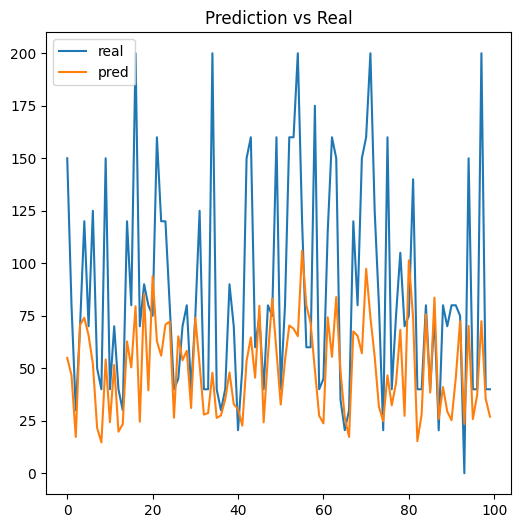

In [41]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[0:100] ,label="real")

plt.plot( pred[0:100] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


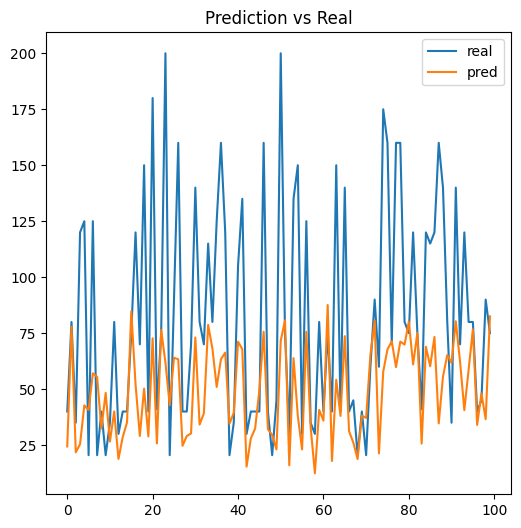

In [42]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[300:400] ,label="real")

plt.plot( pred[300:400] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


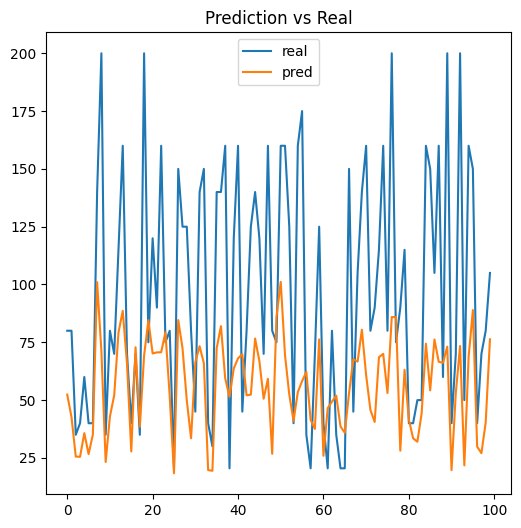

In [43]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[700:800] ,label="real")

plt.plot( pred[700:800] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


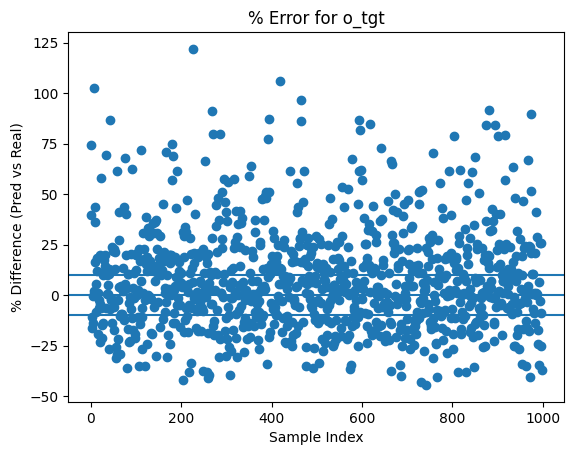

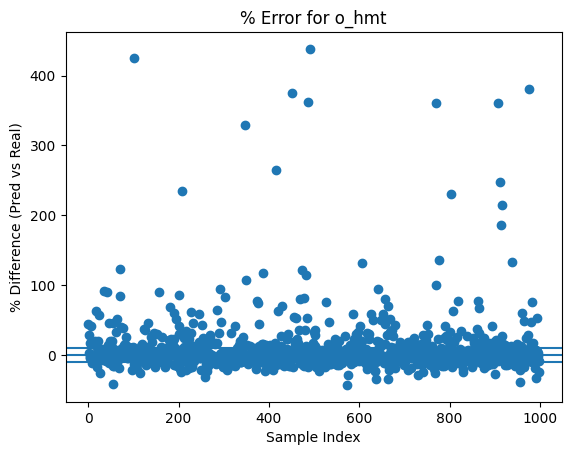

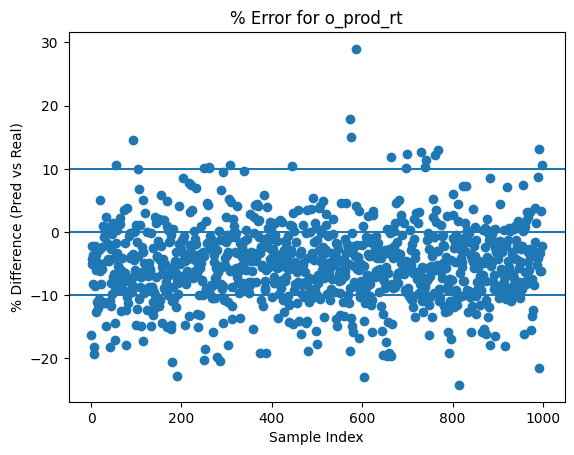

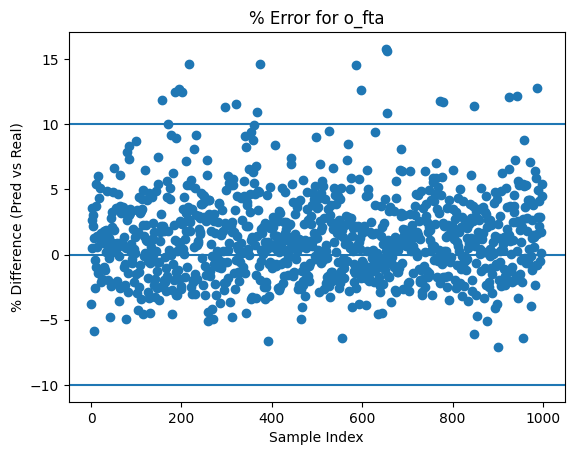

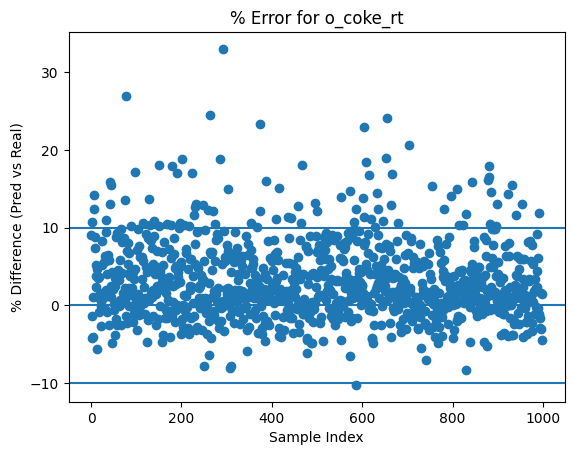

In [44]:

output_names = ['o_tgt', 'o_hmt', 'o_prod_rt', 'o_fta', 'o_coke_rt']

for k in range(5):
    plt.figure()
    plt.scatter(range(len(percent_errors[k])), percent_errors[k])
    
    plt.axhline(0)       # perfect prediction
    plt.axhline(10)      # +10% threshold
    plt.axhline(-10)     # -10% threshold
    
    plt.title(f"% Error for {output_names[k]}")
    plt.xlabel("Sample Index")
    plt.ylabel("% Difference (Pred vs Real)")
    
    plt.show()


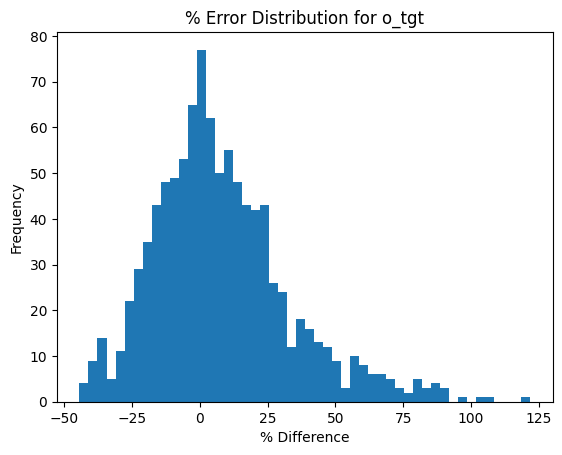

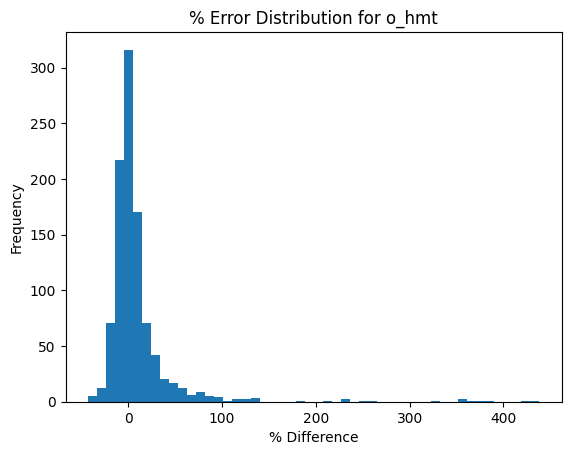

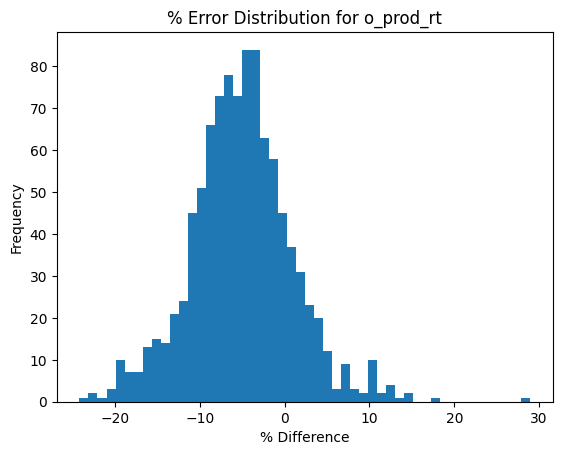

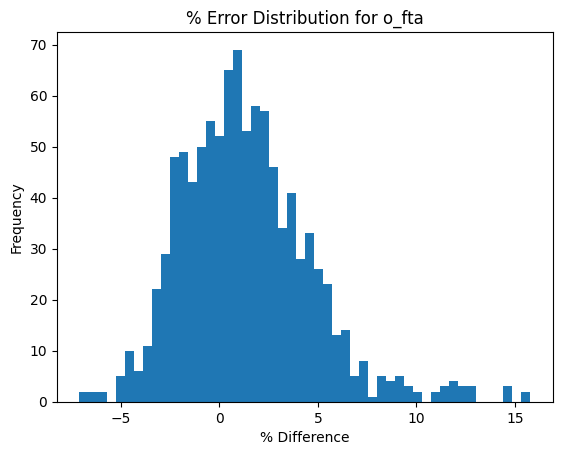

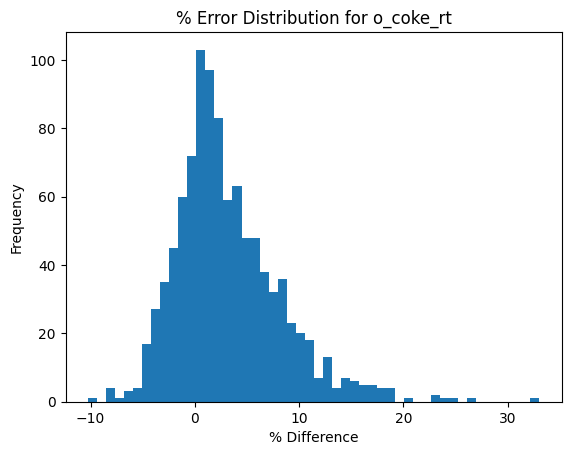

In [45]:

for k in range(5):
    plt.figure()
    plt.hist(percent_errors[k], bins=50)
    plt.title(f"% Error Distribution for {output_names[k]}")
    plt.xlabel("% Difference")
    plt.ylabel("Frequency")
    plt.show()


In [46]:

for k in range(5):
    vals = np.abs(percent_errors[k])
    within_10 = np.mean(vals <= 10) * 100
    within_5  = np.mean(vals <= 5) * 100

    print(output_names[k])
    print("  within 5% :", within_5)
    print("  within 10%:", within_10)


o_tgt
  within 5% : 20.62062062062062
  within 10%: 35.63563563563564
o_hmt
  within 5% : 31.631631631631627
  within 10%: 56.65665665665666
o_prod_rt
  within 5% : 44.24424424424424
  within 10%: 80.38038038038037
o_fta
  within 5% : 87.4874874874875
  within 10%: 97.8978978978979
o_coke_rt
  within 5% : 69.06906906906907
  within 10%: 90.7907907907908


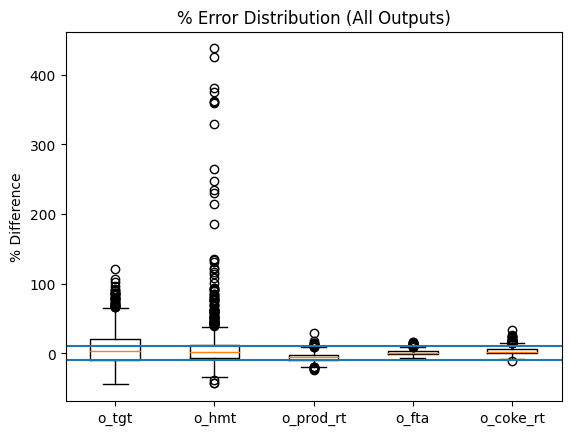

In [47]:

plt.figure()
plt.boxplot(percent_errors)
plt.xticks(range(1,6), output_names)
plt.axhline(10)
plt.axhline(-10)
plt.title("% Error Distribution (All Outputs)")
plt.ylabel("% Difference")
plt.show()


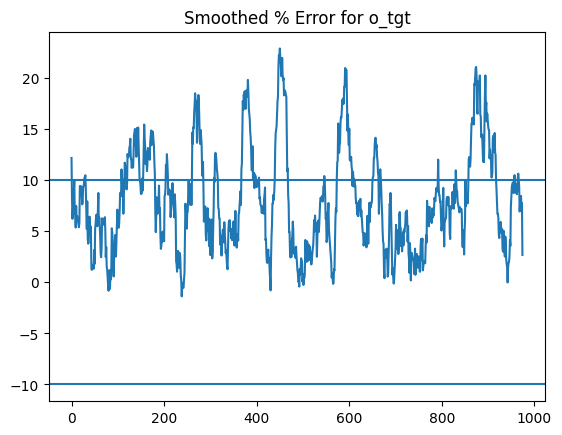

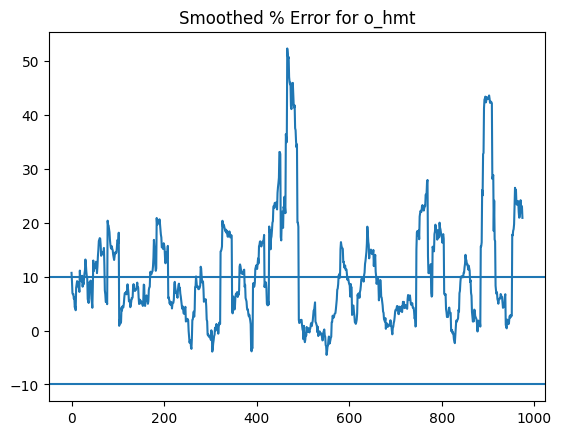

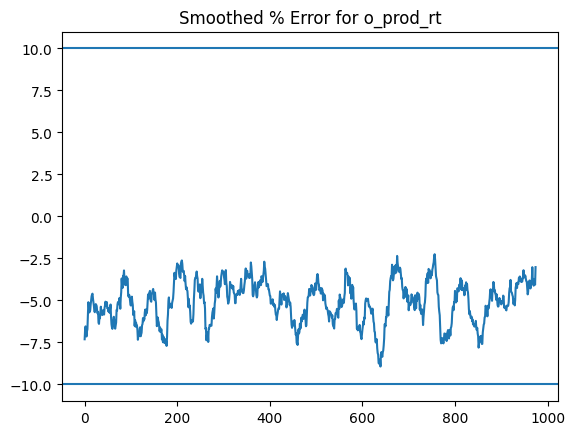

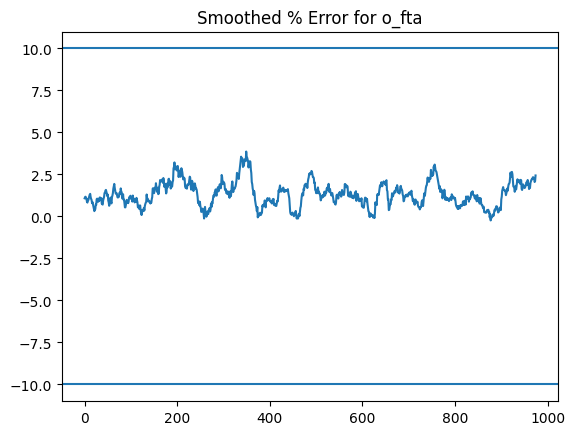

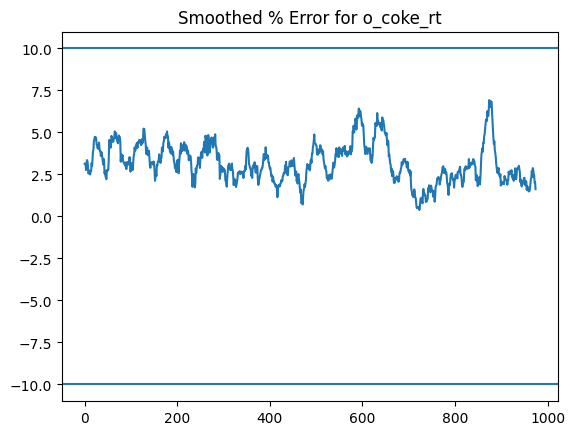

In [48]:

window = 25

for k in range(5):
    vals = np.array(percent_errors[k])
    smooth = np.convolve(vals, np.ones(window)/window, mode='valid')

    plt.figure()
    plt.plot(smooth)
    plt.axhline(10)
    plt.axhline(-10)

    plt.title(f"Smoothed % Error for {output_names[k]}")
    plt.show()


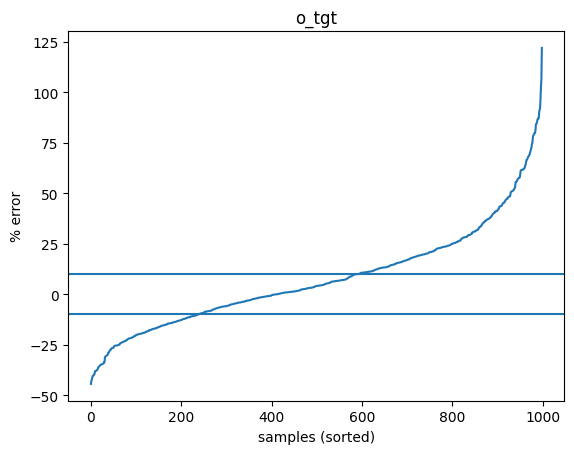

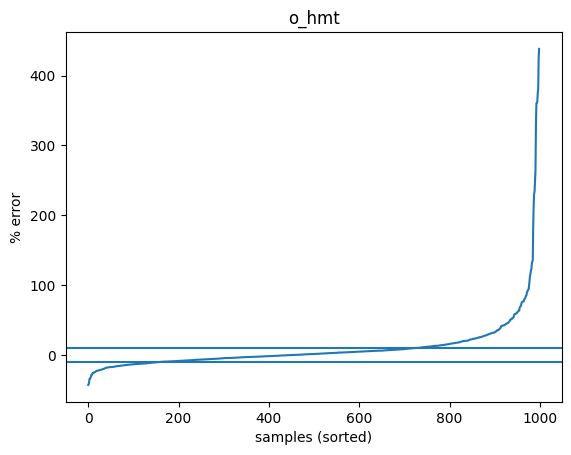

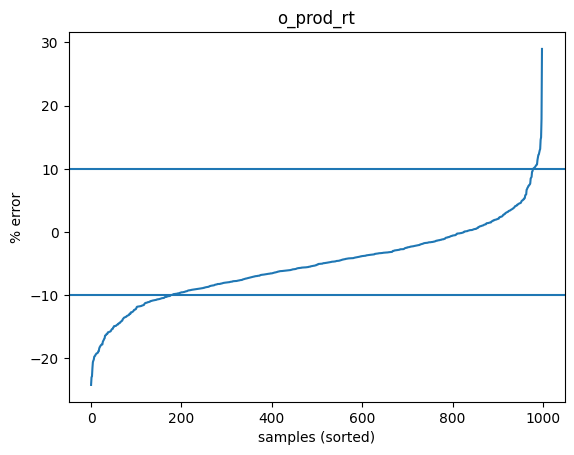

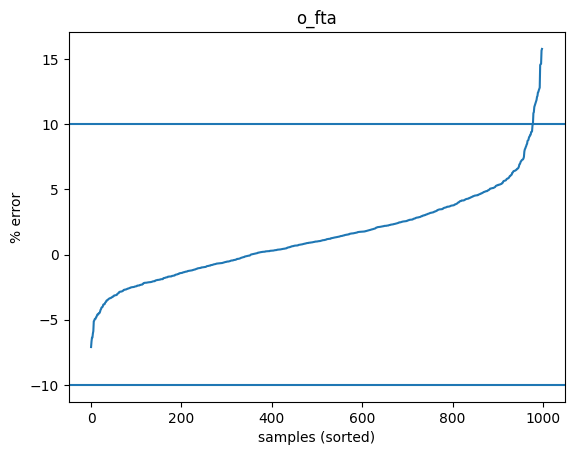

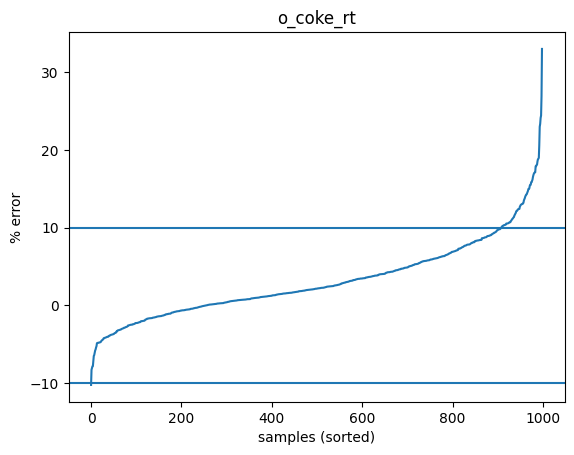

In [50]:

for k in range(5):
    vals = np.sort(np.array(percent_errors[k]))

    plt.figure()
    plt.plot(vals)
    plt.axhline(10)
    plt.axhline(-10)

    plt.title(output_names[k])
    plt.ylabel("% error")
    plt.xlabel("samples (sorted)")
    plt.show()
